# 1️⃣ Problem Statement
The goal of this project is to build a regression model that predicts house prices in Bengaluru based on property features

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [2]:
df = pd.read_csv("bengaluru_house_prices.csv")

In [3]:
df.tail()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.0
13319,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.0


# 2️⃣ Data Cleaning

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [5]:
df.isnull().sum()/len(df)*100

area_type        0.000000
availability     0.000000
location         0.007508
size             0.120120
society         41.306306
total_sqft       0.000000
bath             0.548048
balcony          4.572072
price            0.000000
dtype: float64

In [6]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [7]:
df.drop(columns = "society",inplace = True)

In [8]:
df["balcony"].fillna(df["balcony"].median(),inplace = True)
df["bath"].fillna(df["bath"].median(),inplace = True)
df["location"].fillna(df["location"].mode()[0],inplace = True)
df["size"].fillna(df["size"].mode()[0],inplace = True)

C:\Users\aryam\AppData\Local\Temp\ipykernel_28848\275758367.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["balcony"].fillna(df["balcony"].median(),inplace = True)
C:\Users\aryam\AppData\Local\Temp\ipykernel_28848\275758367.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

In [9]:
df["total_sqft"] = pd.to_numeric(df["total_sqft"],errors = "coerce")

In [10]:
df.isnull().sum()/len(df)*100

area_type       0.000000
availability    0.000000
location        0.000000
size            0.000000
total_sqft      1.854354
bath            0.000000
balcony         0.000000
price           0.000000
dtype: float64

In [11]:
df["total_sqft"].fillna(df["total_sqft"].median(),inplace = True)

C:\Users\aryam\AppData\Local\Temp\ipykernel_28848\414128340.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total_sqft"].fillna(df["total_sqft"].median(),inplace = True)


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13320 non-null  object 
 3   size          13320 non-null  object 
 4   total_sqft    13320 non-null  float64
 5   bath          13320 non-null  float64
 6   balcony       13320 non-null  float64
 7   price         13320 non-null  float64
dtypes: float64(4), object(4)
memory usage: 832.6+ KB


In [13]:
df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200.0,2.0,1.0,51.00


In [14]:
df.shape

(13320, 8)

In [15]:
df["availability"].value_counts()

availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
                 ...  
16-Oct               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: int64

In [16]:
df["availability"]= df["availability"].where(~df["availability"].str.contains(f"\d",regex = True),"Not_moved")



<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\aryam\AppData\Local\Temp\ipykernel_28848\2366769070.py:1: SyntaxWarning: invalid escape sequence '\d'
  df["availability"]= df["availability"].where(~df["availability"].str.contains(f"\d",regex = True),"Not_moved")


In [17]:
df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,Not_moved,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200.0,2.0,1.0,51.00


In [18]:
df["location"].nunique()

1305

In [19]:
df["location"].value_counts().head(20)

location
Whitefield                  541
Sarjapur  Road              399
Electronic City             302
Kanakpura Road              273
Thanisandra                 234
Yelahanka                   213
Uttarahalli                 186
Hebbal                      177
Marathahalli                175
Raja Rajeshwari Nagar       171
Hennur Road                 152
Bannerghatta Road           152
7th Phase JP Nagar          149
Haralur Road                142
Electronic City Phase II    132
Rajaji Nagar                107
Chandapura                  100
Bellandur                    96
KR Puram                     91
Electronics City Phase 1     88
Name: count, dtype: int64

In [20]:
df["location"] = df["location"].str.strip().str.lower()
df["area_type"] = df["area_type"].str.strip().str.lower()
df["availability"] = df["availability"].str.strip().str.lower()

In [21]:
location_counts = df["location"].value_counts()

rare_locations = location_counts[location_counts < 10].index

df["location"] = df["location"].replace(rare_locations, "Other")

In [22]:
df["area_type"].value_counts()

area_type
super built-up  area    8790
built-up  area          2418
plot  area              2025
carpet  area              87
Name: count, dtype: int64

In [23]:
df.describe()

,total_sqft,bath,balcony,price
count,13320.000000,13320.000000,13320.000000,13320.000000
mean,1549.750912,2.688814,1.603378,112.565627
std,1227.502607,1.338754,0.803067,148.971674
min,1.000000,1.000000,0.000000,8.000000
25%,1100.000000,2.000000,1.000000,50.000000
50%,1275.000000,2.000000,2.000000,72.000000
75%,1656.000000,3.000000,2.000000,120.000000
max,52272.000000,40.000000,3.000000,3600.000000


<Axes: >

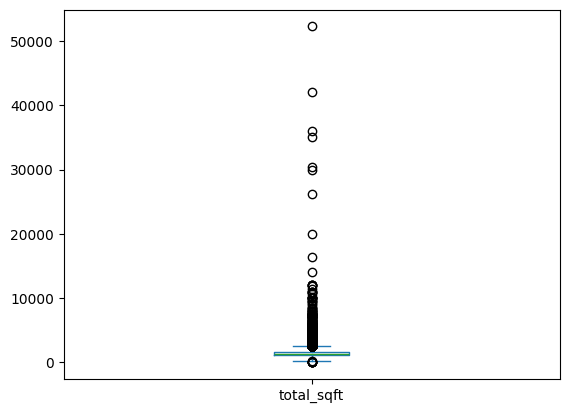

In [24]:
df["total_sqft"].plot(kind = "box")

# 3️⃣Exploratory Data Analysis Insights

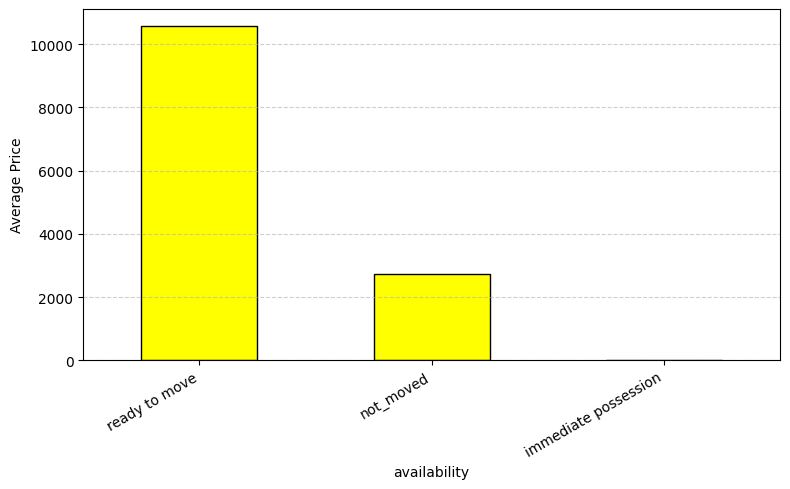

In [25]:
df["availability"].value_counts().plot(kind = "bar",figsize=(8,5),color="yellow",edgecolor="black")
plt.ylabel("Average Price")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()

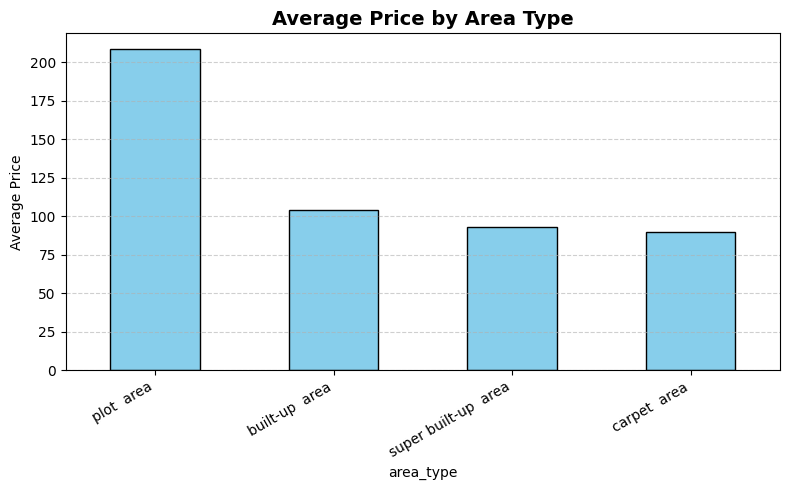

In [26]:
df.groupby("area_type")["price"].mean().sort_values(ascending=False).plot(kind="bar",figsize=(8,5),color="skyblue",edgecolor="black")

plt.title("Average Price by Area Type", fontsize=14, weight="bold")
plt.ylabel("Average Price")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

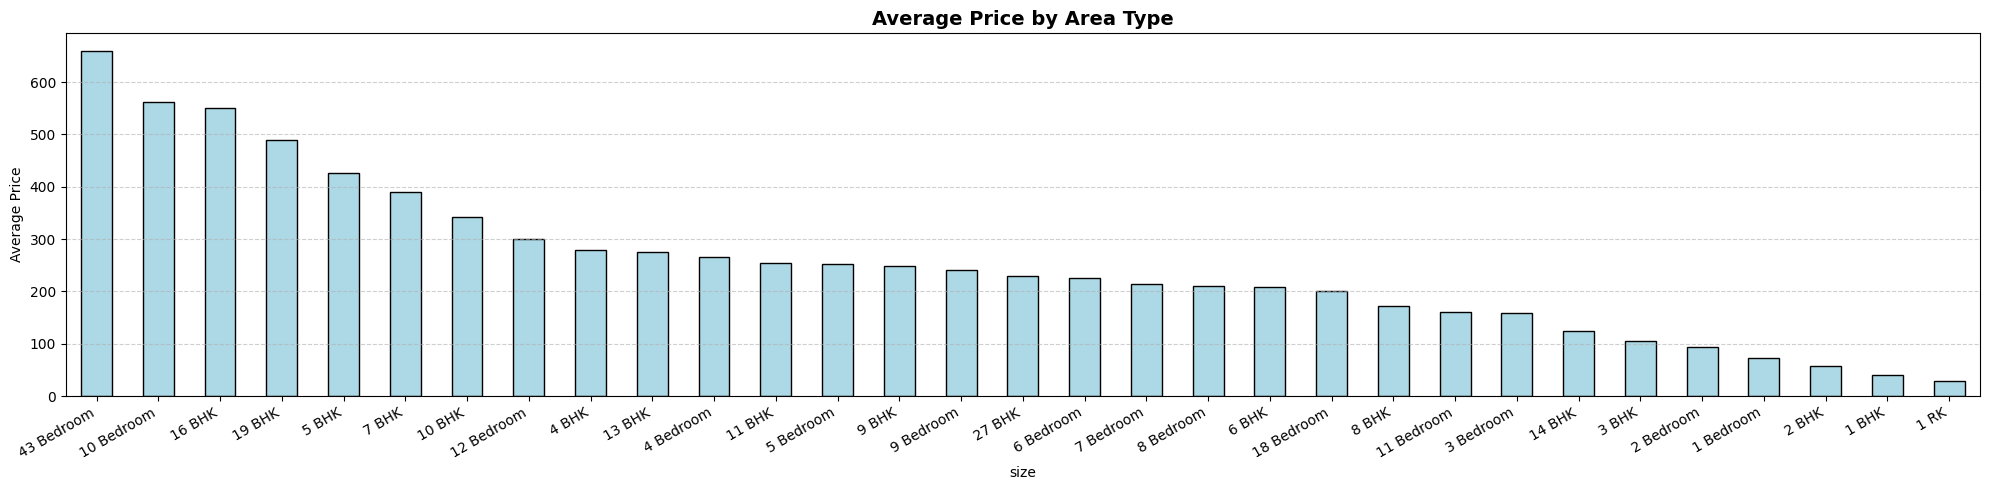

In [27]:
df.groupby("size")["price"].mean().sort_values(ascending=False).plot(kind="bar",figsize=(20,5),color="lightblue",edgecolor="black")

plt.title("Average Price by Area Type", fontsize=14, weight="bold")
plt.ylabel("Average Price")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

<Axes: ylabel='Frequency'>

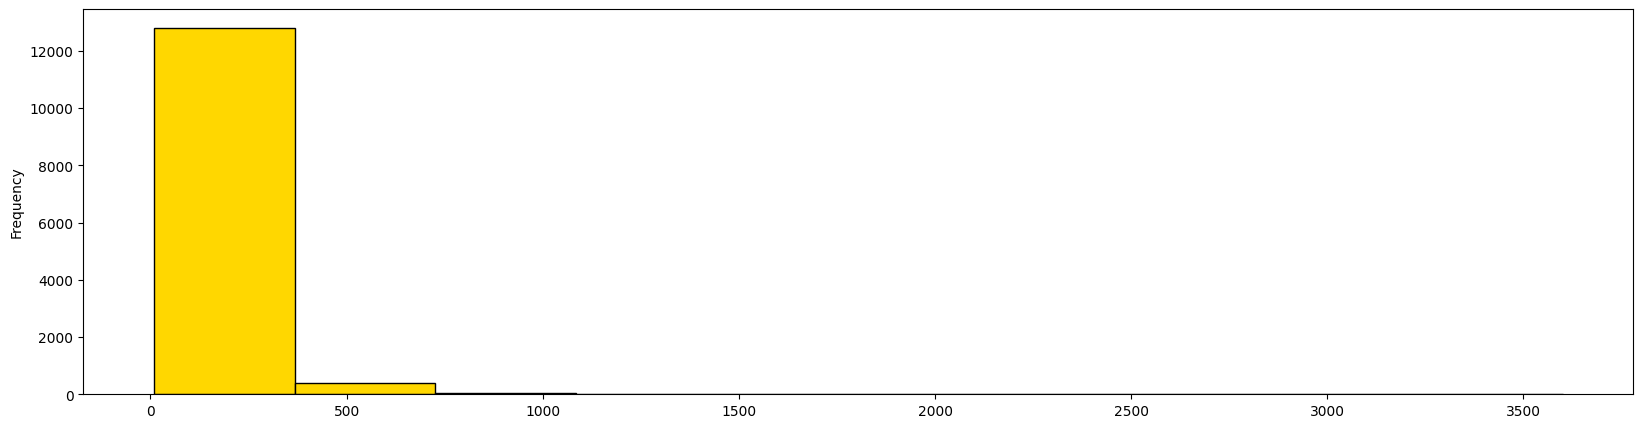

In [28]:
df["price"].plot(kind = "hist",figsize=(20,5),color="gold",edgecolor="black")

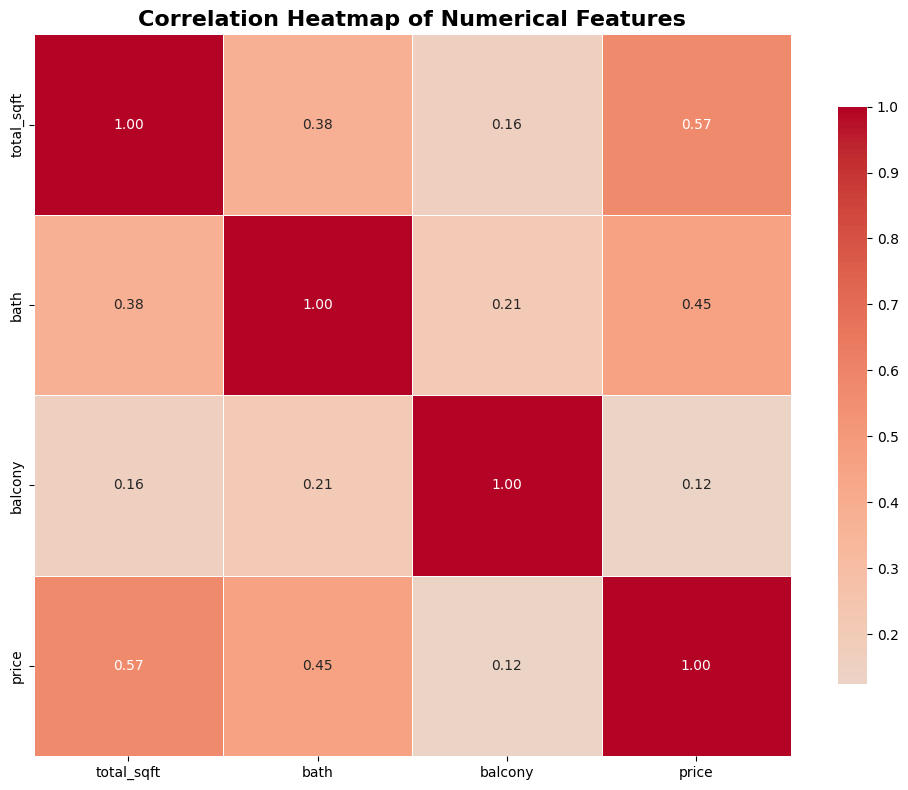

In [29]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.select_dtypes(include="number").corr(),annot=True,fmt=".2f",cmap="coolwarm",center=0,linewidths=0.5,cbar_kws={"shrink":0.8})

plt.title("Correlation Heatmap of Numerical Features", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()


In [30]:
df["bhk"] = df["size"].str.extract("(\d+)").astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\aryam\AppData\Local\Temp\ipykernel_28848\2931866392.py:1: SyntaxWarning: invalid escape sequence '\d'
  df["bhk"] = df["size"].str.extract("(\d+)").astype(float)


In [31]:
df.drop(columns = "size",axis = 1,inplace = True)

In [32]:

df = df[df["price"] < 500]

In [33]:
df.head()

,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,super built-up area,not_moved,electronic city phase ii,1056.0,2.0,1.0,39.07,2.0
1,plot area,ready to move,chikka tirupathi,2600.0,5.0,3.0,120.00,4.0
2,built-up area,ready to move,uttarahalli,1440.0,2.0,3.0,62.00,3.0
3,super built-up area,ready to move,lingadheeranahalli,1521.0,3.0,1.0,95.00,3.0
4,super built-up area,ready to move,kothanur,1200.0,2.0,1.0,51.00,2.0


In [34]:
df["bhk"].max()

np.float64(27.0)

# 4️⃣Modeling Approach

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score


In [36]:
X = df.drop(["price"], axis=1)
y = np.log1p(df["price"])

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5️⃣Pipeline Design

In [38]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)],remainder="passthrough")

In [39]:

pipeline = Pipeline(steps=[("preprocessing", preprocessor),("model", RandomForestRegressor(random_state=42))])

# 6️⃣Hyperparameter Tuning

In [40]:
param_dist = {
    "model__n_estimators": [200, 300, 400, 500, 700],
    "model__max_depth": [10, 15, 20, 25, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=25,             
    cv=5,
    scoring="r2",
    verbose=1,
    random_state=42,
    n_jobs=-1)

In [41]:
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Parameters: {'model__n_estimators': 400, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}


In [42]:
y_pred = best_model.predict(X_test)

y_pred_real = np.expm1(y_pred)
y_test_real = np.expm1(y_test)

print("MAE:", mean_absolute_error(y_test_real, y_pred_real))
print("R2:", r2_score(y_test_real, y_pred_real))

MAE: 22.525331347784096
R2: 0.7245202979377083


# 7️⃣Model Saving

In [43]:

import joblib

joblib.dump(best_model, "ben_house_price_model.pkl")

['ben_house_price_model.pkl']